# ChurnGuard AI — End-to-End Walkthrough

This notebook builds a customer churn prediction system from scratch using the public **IBM Telco Customer Churn dataset** (7,043 customers).

**Pipeline:** Load data → Clean → Engineer features → Train models → Evaluate → Explain predictions → Score new customers

Each step includes *why* it matters, not just *what* the code does.

## Step 1: Load & Clean Data

**Why:** Raw data always has issues — here, `TotalCharges` is stored as text because a few new customers have blank values. We fix types and handle missing values before anything else, or every downstream step silently breaks.

In [1]:
import sys
sys.path.insert(0, '.')
from importlib import import_module

data_prep = import_module('01_data_prep')

df = data_prep.load_and_clean()
print("Shape:", df.shape)
print("Churn rate:", round(df['Churn'].mean()*100, 2), "%")
df.head()

Shape: (7043, 20)
Churn rate: 26.54 %


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


## Step 2: Exploratory Data Analysis

**Why:** Before modeling, we confirm the problem is learnable — is there a real relationship between features and churn, and how imbalanced is the target?

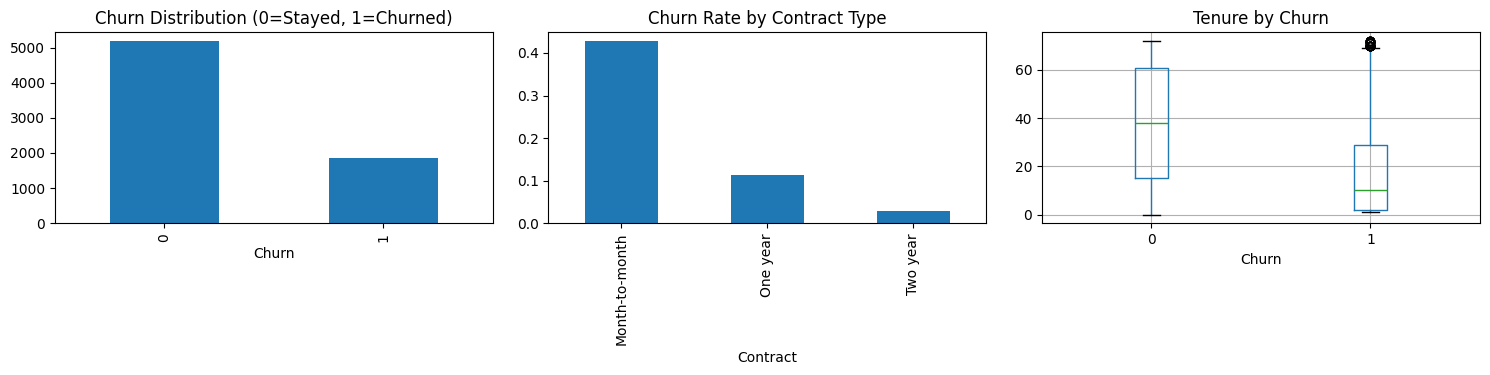


Month-to-month contracts clearly show the highest churn — this will be a key feature.


In [2]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

df['Churn'].value_counts().plot(kind='bar', ax=axes[0], title='Churn Distribution (0=Stayed, 1=Churned)')
df.groupby('Contract')['Churn'].mean().plot(kind='bar', ax=axes[1], title='Churn Rate by Contract Type')
df.boxplot(column='tenure', by='Churn', ax=axes[2])
axes[2].set_title('Tenure by Churn')
plt.suptitle('')
plt.tight_layout()
plt.savefig('eda_overview.png', dpi=100)
plt.show()
print("\nMonth-to-month contracts clearly show the highest churn — this will be a key feature.")

## Step 3: Feature Engineering

**Why:** Raw fields alone underperform. We create tenure buckets, service-count, and contract-risk flags that capture *behavioral patterns* rather than single snapshots — this is usually where the biggest performance gains come from, more than model choice.

In [3]:
feat_eng = import_module('02_feature_engineering')

df_feat = feat_eng.engineer_features(df)
X, y = feat_eng.encode_for_model(df_feat)
print("Feature matrix shape:", X.shape)
X.head()

Feature matrix shape: (7043, 38)


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,avg_charge_per_tenure,num_services,is_month_to_month,is_high_charge,gender_Male,Partner_Yes,...,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,tenure_bucket_6-12mo,tenure_bucket_1-2yr,tenure_bucket_2-4yr,tenure_bucket_4yr+
0,0,1,29.85,29.85,29.850000,1,1,0,False,True,...,False,False,True,False,True,False,False,False,False,False
1,0,34,56.95,1889.50,55.573529,2,0,0,True,False,...,True,False,False,False,False,True,False,False,True,False
2,0,2,53.85,108.15,54.075000,2,1,0,True,False,...,False,False,True,False,False,True,False,False,False,False
3,0,45,42.30,1840.75,40.905556,3,0,0,True,False,...,True,False,False,False,False,False,False,False,True,False
4,0,2,70.70,151.65,75.825000,0,1,0,False,False,...,False,False,True,False,True,False,False,False,False,False


## Step 4: Train Models

**Why two models:** Logistic Regression gives an interpretable baseline. XGBoost typically performs better on tabular data because it captures nonlinear interactions (e.g. "low tenure AND month-to-month AND high charges" compounding risk). We also handle class imbalance explicitly — otherwise the model would just learn to predict "no churn" for everyone and still look 73% accurate.

In [4]:
train_mod = import_module('03_train_model')
xgb_model, X_test, y_test, xgb_probs = train_mod.main()

MODEL 1: Logistic Regression (baseline)
ROC-AUC: 0.845
PR-AUC:  0.651

MODEL 2: XGBoost (production model)
ROC-AUC: 0.839
PR-AUC:  0.646

Classification report at threshold=0.35:
              precision    recall  f1-score   support

      Stayed       0.93      0.64      0.76      1035
     Churned       0.47      0.87      0.61       374

    accuracy                           0.70      1409
   macro avg       0.70      0.75      0.68      1409
weighted avg       0.81      0.70      0.72      1409

Confusion Matrix:
                Predicted Stay   Predicted Churn
Actual Stay     664              371
Actual Churn    50               324

Lift check: contacting the top 10% highest-risk customers catches 108/374 (28.9%) of all actual churners.

Model saved to models/churnguard_xgb.joblib


## Step 5: Explainability (SHAP)

**Why:** A risk score alone isn't actionable. The retention team needs to know *why* someone is at risk so they can design the right intervention — a discount for price-sensitive customers, onboarding help for disengaged new customers, etc.

In [5]:
explain_mod = import_module('04_explainability')
result_df, shap_values = explain_mod.explain_top_risk_customers(n=5)

Top 5 highest-risk customers and WHY:

Customer #2577 — Churn risk: 98.3%
    + tenure = 1  (pushed risk up by 1.040)
    + is_month_to_month = 1  (pushed risk up by 0.707)
    + avg_charge_per_tenure = 94.6  (pushed risk up by 0.515)

Customer #2208 — Churn risk: 98.2%
    + tenure = 1  (pushed risk up by 1.045)
    + is_month_to_month = 1  (pushed risk up by 0.706)
    + MonthlyCharges = 100.8  (pushed risk up by 0.377)

Customer #3380 — Churn risk: 98.0%
    + tenure = 1  (pushed risk up by 1.018)
    + is_month_to_month = 1  (pushed risk up by 0.693)
    + TotalCharges = 95.1  (pushed risk up by 0.375)

Customer #4800 — Churn risk: 97.9%
    + tenure = 1  (pushed risk up by 1.048)
    + is_month_to_month = 1  (pushed risk up by 0.690)
    + TotalCharges = 94.0  (pushed risk up by 0.368)

Customer #6866 — Churn risk: 97.8%
    + tenure = 1  (pushed risk up by 1.003)
    + is_month_to_month = 1  (pushed risk up by 0.691)
    + InternetService_Fiber optic = True  (pushed risk up by 0.

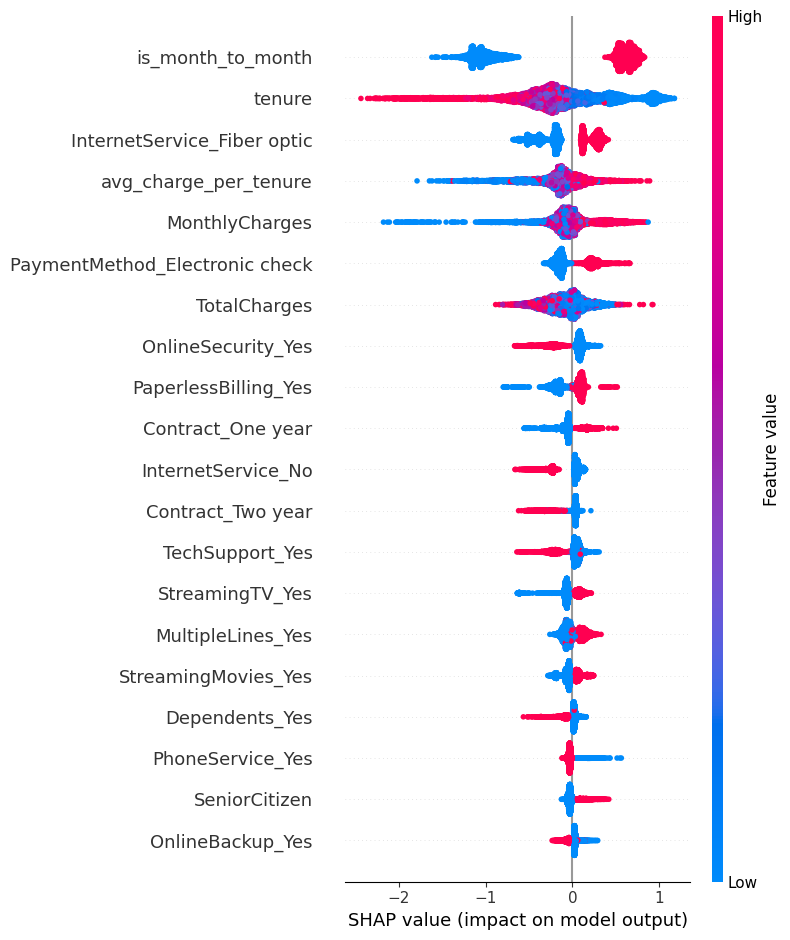

In [6]:
import shap
import matplotlib.pyplot as plt

# Use the same feature matrix that was fed into the explainer
shap.summary_plot(shap_values, X, show=False)
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=100, bbox_inches='tight')
plt.show()

## Step 6: Score a New Customer

**Why:** This simulates real production use — a new customer record comes in (e.g. from a daily batch job or a signup event), and ChurnGuard returns a risk score plus the top reasons behind it.

In [7]:
score_mod = import_module('05_score_new_customer')

new_customer = {
    'gender': 'Female', 'SeniorCitizen': 0, 'Partner': 'No',
    'Dependents': 'No', 'tenure': 2, 'PhoneService': 'Yes',
    'MultipleLines': 'No', 'InternetService': 'Fiber optic',
    'OnlineSecurity': 'No', 'OnlineBackup': 'No',
    'DeviceProtection': 'No', 'TechSupport': 'No',
    'StreamingTV': 'Yes', 'StreamingMovies': 'Yes',
    'Contract': 'Month-to-month', 'PaperlessBilling': 'Yes',
    'PaymentMethod': 'Electronic check', 'MonthlyCharges': 95.5,
    'TotalCharges': '191.0',
}
risk, reasons = score_mod.score_customer(new_customer)

Churn risk: 82.3%
Top risk drivers:
  - tenure = 2  (impact: +0.613)
  - is_month_to_month = 1  (impact: +0.522)
  - avg_charge_per_tenure = 95.5  (impact: +0.372)


## Next Steps (Beyond This Prototype)

This notebook is the **3-day prototype tier**. To move toward production:

1. **Automate scoring** — wrap `05_score_new_customer.py` in a FastAPI endpoint or scheduled batch job
2. **Connect real data** — replace the CSV with a live database/warehouse query
3. **Add monitoring** — track prediction drift and retrain monthly/quarterly
4. **Set a business threshold** — tune the 0.35 cutoff based on actual cost of a missed churner vs. a wasted retention offer
5. **Build a dashboard** — surface risk scores to the retention team directly (e.g. Streamlit, or push into a CRM)
